System becomes stable at x = 4981.764
Slope of stabilized region: 4.7140e-05
Intrinsic mutation time: 21213.2521


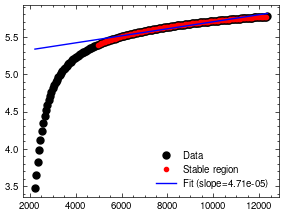

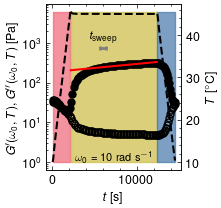

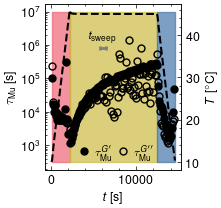

10140.0
0.4780030876265945


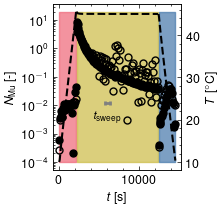

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
from matplotlib.ticker import LogLocator
import os

plt.style.use(['science', 'nature', 'bright'])

# Use the default color cycle from matplotlib
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
marker = ["o", "o"]

# Load data from CSV file, skipping irrelevant rows
data_up = pd.read_csv('../data/processed/dmta/mc-1_5-heatup45-isothermal10000_sweep_freq_Tup_10rads.csv', skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding="utf-16")
data_iso = pd.read_csv('../data/processed/dmta/mc-1_5-heatup45-isothermal10000_sweep_freq_Tiso_10rads.csv', skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding="utf-16")
data_down = pd.read_csv('../data/processed/dmta/mc-1_5-heatup45-isothermal10000_sweep_freq_Tdown_10rads.csv', skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding="utf-16")

# Drop any fully empty rows
data_up = data_up.dropna(how='all')
data_iso = data_iso.dropna(how='all')
data_down = data_down.dropna(how='all')


# Assuming columns are named correctly in the dataset after skipping rows
time_up = data_up['Time'] 
storage_modulus_up = np.log10(data_up['Storage Modulus'])
loss_modulus_up = np.log10(data_up['Loss Modulus'])
temperature_up = data_up['Temperature']

time_iso = data_iso['Time'] + data_up['Time'].max()
storage_modulus_iso = np.log10(data_iso['Storage Modulus'])
loss_modulus_iso = np.log10(data_iso['Loss Modulus'])
temperature_iso = data_iso['Temperature']

time_down = data_down['Time'] + data_iso['Time'].max() + data_up['Time'].max()
storage_modulus_down = np.log10(data_down['Storage Modulus'])
loss_modulus_down = np.log10(data_down['Loss Modulus'])
temperature_down = data_down['Temperature']

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Example data (replace with your own)
y = np.log(10**storage_modulus_iso)
x = time_iso

# --- 1. Compute derivative ---
dy_dx = np.gradient(y, x)

# --- 2. Smooth derivative (optional) ---
dy_dx_smooth = np.convolve(dy_dx, np.ones(5)/5, mode='same')

# --- 3. Find stabilization region ---
idx_max = np.argmax(np.abs(dy_dx_smooth))              # index of maximum derivative
threshold = np.max(np.abs(dy_dx_smooth)) * 0.05        # 5% of max slope
stable_mask = (np.abs(dy_dx_smooth) < threshold) & (np.arange(len(x)) > idx_max)

# Find the first stable point after the max derivative
stable_indices = np.where(stable_mask)[0]
if len(stable_indices) > 0:
    start = stable_indices[0]
    print(f"System becomes stable at x = {x[start]:.3f}")
else:
    print("No stabilization region found.")

# --- 4. Fit linear model in stabilized region ---
if len(stable_indices) > 0:
    end = stable_indices[-1]
    slope, intercept, r, p, stderr = linregress(x[start:end], y[start:end])
    intrinsic_mutation_time = 1 / slope

    print(f"Slope of stabilized region: {slope:.4e}")
    print(f"Intrinsic mutation time: {intrinsic_mutation_time:.4f}")
else:
    slope = intercept = intrinsic_mutation_time = np.nan




# (Optional: plot to verify)
plt.plot(x, y, 'ko', markersize=5, label='Data')
plt.plot(x[start:end], y[start:end], 'ro', label='Stable region')
plt.plot(x, slope*x + intercept, 'b-', label=f'Fit (slope={slope:.2e})')
plt.legend()
plt.show()



fig, ax1 = plt.subplots(figsize=(2.33, 2.2))

# Plot Storage and Loss Modulus on left Y-axis

# Shade the left side red and the right side blue
plt.fill_betweenx([10**0.0, 10**3.8], data_up['Time'].min(), data_up['Time'].max(), color=colors[1], alpha=0.7)  # Adjust y-limits as needed
plt.fill_betweenx([10**0.0, 10**3.8], data_up['Time'].max() + data_iso['Time'].min(), data_up['Time'].max() + data_iso['Time'].max(), color=colors[3], alpha=0.7)   # Adjust y-limits as needed
plt.fill_betweenx([10**0.0, 10**3.8], data_up['Time'].max() + data_iso['Time'].max() + data_down['Time'].min(), 
                  data_up['Time'].max() + data_iso['Time'].max() + data_down['Time'].max(), color=colors[0], alpha=0.7)   # Adjust y-limits as needed


ax1.set_yscale('log')
ax1.set_xlabel('$t$ [s]', fontsize=9)
ax1.set_ylabel('$G^{\prime}(\omega_0,T), G^{\prime \prime}(\omega_0,T)~\mathrm{[Pa]}$', fontsize=9)
ax1.plot(time_up, 10**storage_modulus_up, 'o', markersize=5, label='$G^{\prime}(\omega)$', color='k', markevery=3)
ax1.plot(time_up, 10**loss_modulus_up, 'o', markersize=5, fillstyle="none", label='$G^{\prime\prime}(\omega)$', color='k', markevery=3)

ax1.plot(time_iso, 10**storage_modulus_iso, 'o', markersize=5, color='k', markevery=3)
ax1.plot(time_iso, 10**loss_modulus_iso, 'o', markersize=5, fillstyle="none", color='k', markevery=3)


ax1.plot(time_down, 10**storage_modulus_down, 'o', markersize=5, color='k', markevery=2)
ax1.plot(time_down, 10**loss_modulus_down, 'o', markersize=5, fillstyle="none", color='k', markevery=2)

ax1.plot(x, np.exp(slope*x + intercept), 'r-', lw=1.5, label=f'Fit (slope={slope:.2e})')


ax1.tick_params(labelsize=9)
#ax1.legend(loc='upper left')

# Create second Y-axis for Temperature
ax2 = ax1.twinx()
ax2.set_ylabel('$T$ [$^{\circ}$C]', fontsize=9)
ax2.plot(time_up, temperature_up, '--', label='Temperature Up', color='k', lw=1.5)
ax2.plot(time_iso, temperature_iso, '--', label='Temperature Iso', color='k', lw=1.5)
ax2.plot(time_down, temperature_down, '--', label='Temperature Iso', color='k', lw=1.5)
ax2.hlines(y=37, xmin=5700, xmax=5700+694.7999999999998, color='gray', linestyle='-', linewidth=2)  # Horizontal line
ax2.vlines(x=5700, ymin=36.5, ymax=37.5, color='gray', linewidth=2)  # Left vertical cap
ax2.vlines(x=5700+694.7999999999998, ymin=36.5, ymax=37.5, color='gray', linewidth=2)  # Right vertical cap
ax2.tick_params(axis='y', labelsize=9)
#ax2.legend(loc='upper right')

text = f"$\\omega_0 = 10~\\rm{{rad~s}}^{{-1}}$"  # Replace with your actual temperature value
text2 = f"$t_{{\\text{{sweep}}}}$"  # Replace with your actual temperature value

plt.text(0.5, 0.085, text, horizontalalignment='center', verticalalignment='center',
                 transform=plt.gca().transAxes, fontsize=8)
plt.text(0.42, 0.80, text2, horizontalalignment='center', verticalalignment='center',
                 transform=plt.gca().transAxes, fontsize=8)

#plt.xscale("log")
plt.tight_layout()

# ---------------- Ensure output folder exists ----------------
out_dir = "../figures/main/dmta_and_mutation"
os.makedirs(out_dir, exist_ok=True)

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "dmta_early_stop_10rads.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()

def central_difference_derivative(f_values, x_values):
    """
    Compute the derivative of a function at given x_points using the central difference method.
    
    Parameters:
    f_values (numpy array): Array of function values f(x).
    x_values (numpy array): Array of x values corresponding to f(x).
    
    Returns:
    numpy array: Array of derivative values f'(x).
    """
    f_values = np.array(f_values)
    x_values = np.array(x_values)
    
    if len(f_values) != len(x_values):
        raise ValueError("The length of f_values and x_values must be the same.")
    
    n = len(x_values)
    derivative_values = np.zeros(n)
    
    for i in range(1, n-1):
        h = x_values[i+1] - x_values[i-1]
        derivative_values[i] = (f_values[i+1] - f_values[i-1]) / (h)
    
    # For endpoints, use forward/backward difference (though central is more accurate and preferred)
    derivative_values[0] = (f_values[1] - f_values[0]) / (x_values[1] - x_values[0])
    derivative_values[-1] = (f_values[-1] - f_values[-2]) / (x_values[-1] - x_values[-2])
    
    return derivative_values

# Concatenate all segments manually
time_tot = np.concatenate([time_up, time_iso, time_down])
storage_modulus_tot = np.concatenate([storage_modulus_up, storage_modulus_iso, storage_modulus_down])
loss_modulus_tot = np.concatenate([loss_modulus_up, loss_modulus_iso, loss_modulus_down])
temperature_tot = np.concatenate([temperature_up, temperature_iso, temperature_down])
complex_modulus_tot = np.sqrt(np.power(storage_modulus_tot, 2) + np.power(loss_modulus_tot, 2))

derivatives_storage = central_difference_derivative(np.log(storage_modulus_tot), time_tot)
mutation_time_tot_storage = (np.abs(derivatives_storage))**(-1)

derivatives_loss = central_difference_derivative(np.log(loss_modulus_tot), time_tot)
mutation_time_tot_loss = (np.abs(derivatives_loss))**(-1)


derivatives_complex = central_difference_derivative(np.log(complex_modulus_tot), time_tot)
mutation_time_tot_complex = (np.abs(derivatives_complex))**(-1)


######################################################################################################################################


fig, ax1 = plt.subplots(figsize=(2.33, 2.2))

# Plot Storage and Loss Modulus on left Y-axis

# Shade the left side red and the right side blue
plt.fill_betweenx([10**2.5, 10**7], data_up['Time'].min(), data_up['Time'].max(), color=colors[1], alpha=0.7)  # Adjust y-limits as needed
plt.fill_betweenx([10**2.5, 10**7], data_up['Time'].max() + data_iso['Time'].min(), data_up['Time'].max() + data_iso['Time'].max(), color=colors[3], alpha=0.7)   # Adjust y-limits as needed
plt.fill_betweenx([10**2.5, 10**7], data_up['Time'].max() + data_iso['Time'].max() + data_down['Time'].min(), 
                  data_up['Time'].max() + data_iso['Time'].max() + data_down['Time'].max(), color=colors[0], alpha=0.7)   # Adjust y-limits as needed

ax1.set_xlabel('$t$ [s]', fontsize=9)
ax1.set_ylabel('$\\tau_{\\rm{Mu}}$~[s]',fontsize=9)
ax1.plot(time_tot, mutation_time_tot_storage, 'o', markersize=5, color='k', markevery=2, label="$\\tau_{\\rm{Mu}}^{G^{\\prime}}$")
ax1.plot(time_tot, mutation_time_tot_loss, 'o', fillstyle="none", markersize=5, color='k', markevery=2, label="$\\tau_{\\rm{Mu}}^{G^{\prime\prime}}$")
#ax1.plot(time_tot, mutation_time_tot_complex, 'o', markersize=6, color='b', markevery=2, label="$\\tau_{\\rm{Mu}}^{G^{\\ast}}$")
ax1.tick_params(labelsize=9)
ax1.set_yscale("log")
ax1.legend(loc='lower center', fontsize=8, handletextpad=0.0, ncol=2, columnspacing=0.0)


# Create second Y-axis for Temperature
ax2 = ax1.twinx()
ax2.set_ylabel('$T$ [$^{\circ}$C]', fontsize=9)
ax2.plot(time_up, temperature_up, '--', label='Temperature Up', color='k', lw=1.5)
ax2.plot(time_iso, temperature_iso, '--', label='Temperature Iso', color='k', lw=1.5)
ax2.plot(time_down, temperature_down, '--', label='Temperature Iso', color='k', lw=1.5)
ax2.hlines(y=37, xmin=5700, xmax=5700+694.7999999999998, color='gray', linestyle='-', linewidth=2)  # Horizontal line
ax2.vlines(x=5700, ymin=36.5, ymax=37.5, color='gray', linewidth=2)  # Left vertical cap
ax2.vlines(x=5700+694.7999999999998, ymin=36.5, ymax=37.5, color='gray', linewidth=2)  # Right vertical cap
ax2.tick_params(axis='y', labelsize=9)
#ax2.legend(loc='upper right')

text = f"$\\omega_0 = 10~\\rm{{rad~s}}^{{-1}}$"  # Replace with your actual temperature value
text2 = f"$t_{{\\text{{sweep}}}}$"  # Replace with your actual temperature value

#plt.text(0.2, 0.085, text, horizontalalignment='center', verticalalignment='center',
#                 transform=plt.gca().transAxes, fontsize=14)
plt.text(0.42, 0.80, text2, horizontalalignment='center', verticalalignment='center',
                 transform=plt.gca().transAxes, fontsize=8)

plt.tight_layout()
out_file = os.path.join(out_dir, "dmta_mutation_time_early_stop_10rads.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()
#time_up = data_up['Time'] 
#storage_modulus_up = np.log10(data_up['Storage Modulus'])
#loss_modulus_up = np.log10(data_up['Loss Modulus'])
#temperature_up = data_up['Temperature']

#time_iso = data_iso['Time'] + data_up['Time'].max()
#storage_modulus_iso = np.log10(data_iso['Storage Modulus'])
#loss_modulus_iso = np.log10(data_iso['Loss Modulus'])
#temperature_iso = data_iso['Temperature']

#time_down = data_down['Time'] + data_iso['Time'].max() + data_up['Time'].max()
#storage_modulus_down = np.log10(data_down['Storage Modulus'])
#loss_modulus_down = np.log10(data_down['Loss Modulus'])
#temperature_down = data_down['Temperature']

derivatives_storage_up = central_difference_derivative(np.log(storage_modulus_up), time_up)
mutation_time_storage_up = (np.abs(derivatives_storage_up))**(-1)

derivatives_loss_up = central_difference_derivative(np.log(loss_modulus_up), time_up)
mutation_time_loss_up = (np.abs(derivatives_loss_up))**(-1)

derivatives_storage_iso = central_difference_derivative(np.log(storage_modulus_iso), time_iso)
mutation_time_storage_iso = (np.abs(derivatives_storage_iso))**(-1)

derivatives_loss_iso = central_difference_derivative(np.log(loss_modulus_iso), time_iso)
mutation_time_loss_iso = (np.abs(derivatives_loss_iso))**(-1)

derivatives_storage_down = central_difference_derivative(np.log(storage_modulus_down), time_down)
mutation_time_storage_down = (np.abs(derivatives_storage_down))**(-1)

derivatives_loss_down = central_difference_derivative(np.log(loss_modulus_down), time_down)
mutation_time_loss_down = (np.abs(derivatives_loss_down))**(-1)

time_iso_diff = time_iso.iloc[-1] - time_iso.iloc[0]

#time_iso_diff = intrinsic_mutation_time

print(time_iso_diff)

######################################################################################################################################

fig, ax1 = plt.subplots(figsize=(2.33, 2.2))

# Plot Storage and Loss Modulus on left Y-axis

# Shade the left side red and the right side blue
plt.fill_betweenx([10**-4, 20**1], data_up['Time'].min(), data_up['Time'].max(), color=colors[1], alpha=0.7)  # Adjust y-limits as needed
plt.fill_betweenx([10**-4, 20**1], data_up['Time'].max() + data_iso['Time'].min(), data_up['Time'].max() + data_iso['Time'].max(), color=colors[3], alpha=0.7)   # Adjust y-limits as needed
plt.fill_betweenx([10**-4, 20**1], data_up['Time'].max() + data_iso['Time'].max() + data_down['Time'].min(), 
                  data_up['Time'].max() + data_iso['Time'].max() + data_down['Time'].max(), color=colors[0], alpha=0.7)   # Adjust y-limits as needed

ax1.set_xlabel('$t$ [s]', fontsize=9)
ax1.set_ylabel('$N_{\\rm{Mu}}$~[-]',fontsize=9)

ax1.plot(time_up, np.gradient(time_up) / mutation_time_storage_up, 'o', markersize=5, color='k', markevery=2, label="$N_{\\rm{Mu}}^{G^{\\prime}}$")
ax1.plot(time_iso, time_iso_diff / mutation_time_storage_iso, 'o', markersize=5, color='k', markevery=2)
ax1.plot(time_down, np.gradient(time_down) / mutation_time_storage_down, 'o', markersize=5, color='k', markevery=2)


ax1.plot(time_up,  np.gradient(time_up) / mutation_time_loss_up, 'o', fillstyle="none", markersize=5, color='k', markevery=2, label="$N_{\\rm{Mu}}^{G^{\prime\prime}}$")
ax1.plot(time_iso,  time_iso_diff / mutation_time_loss_iso, 'o', fillstyle="none", markersize=5, color='k', markevery=2)
ax1.plot(time_down,  np.gradient(time_down) / mutation_time_loss_down, 'o', fillstyle="none", markersize=5, color='k', markevery=2)


# Calculate the y-value (constant)
y_value = time_iso_diff / intrinsic_mutation_time
print(y_value)

# Determine start and end of x-range
x_start =  data_up['Time'].max() + data_iso['Time'].min()
x_end = data_up['Time'].max() + data_iso['Time'].max()

# Plot the horizontal line
#ax1.hlines(
#    y=y_value,
#    xmin=x_start,
#    xmax=x_end,
#    color='r',          # red line (you can change this)
#    linewidth=1.5,
#    linestyle='-',
#    label=r'Best-fit slope, $\frac{d \ln g}{dt}$'
#)



#ax1.plot(time_tot, mutation_time_tot_complex, 'o', markersize=6, color='b', markevery=2, label="$\\tau_{\\rm{Mu}}^{G^{\\ast}}$")
ax1.tick_params(labelsize=9)
ax1.set_yscale("log")
#ax1.legend(loc='lower center', frameon=True, fontsize=14, handletextpad=0.0, ncol=2, columnspacing=0.0)
# Force major ticks at each decade
plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Force minor ticks between decades (2, 3, ..., 9)
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))

# Create second Y-axis for Temperature
ax2 = ax1.twinx()
ax2.set_ylabel('$T$ [$^{\circ}$C]', fontsize=9)
ax2.plot(time_up, temperature_up, '--', label='Temperature Up', color='k', lw=1.5)
ax2.plot(time_iso, temperature_iso, '--', label='Temperature Iso', color='k', lw=1.5)
ax2.plot(time_down, temperature_down, '--', label='Temperature Iso', color='k', lw=1.5)
ax2.hlines(y=24, xmin=5700, xmax=5700+694.7999999999998, color='gray', linestyle='-', linewidth=2)  # Horizontal line
ax2.vlines(x=5700, ymin=23.5, ymax=24.5, color='gray', linewidth=2)  # Left vertical cap
ax2.vlines(x=5700+694.7999999999998, ymin=23.5, ymax=24.5, color='gray', linewidth=2)  # Right vertical cap
ax2.tick_params(axis='y', labelsize=9)
#ax2.legend(loc='upper right')

text = f"$\\omega_0 = 10~\\rm{{rad~s}}^{{-1}}$"  # Replace with your actual temperature value
text2 = f"$t_{{\\text{{sweep}}}}$"  # Replace with your actual temperature value

#plt.text(0.2, 0.085, text, horizontalalignment='center', verticalalignment='center',
#                 transform=plt.gca().transAxes, fontsize=14)
#plt.text(0.42, 0.40, text2, horizontalalignment='center', verticalalignment='center',
#                 transform=plt.gca().transAxes, fontsize=8)

plt.text(0.42, 0.32, text2, horizontalalignment='center', verticalalignment='center',
                 transform=plt.gca().transAxes, fontsize=8)

plt.tight_layout()
out_file = os.path.join(out_dir, "dmta_mutation_number_early_stop_10rads.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()

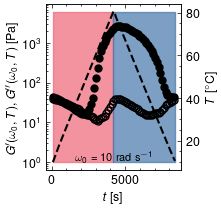

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
plt.style.use(['science', 'nature', 'bright'])

# Use the default color cycle from matplotlib
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
marker = ["o", "o"]

# Load data from CSV file, skipping irrelevant rows
data_dmta = pd.read_csv('../data/processed/dmta/mc_1-5_tempramp_10_1.csv', skiprows=[0,1,2,4,5], sep="\t", decimal=",", encoding="utf-8")


# Drop any fully empty rows
data_dmta = data_dmta.dropna(how='all')



# Assuming columns are named correctly in the dataset after skipping rows
time_dmta = data_dmta['Time'] 
storage_modulus_dmta = np.log10(data_dmta['Storage Modulus'])
loss_modulus_dmta = np.log10(data_dmta['Loss Modulus'])
temperature_dmta = data_dmta['Temperature']



fig, ax1 = plt.subplots(figsize=(2.33, 2.2))

# Plot Storage and Loss Modulus on left Y-axis

# Shade the left side red and the right side blue
plt.fill_betweenx([10**0.0, 10**3.8], data_dmta['Time'].min(), data_dmta['Time'].max() / 2, color=colors[1], alpha=0.7)  # Adjust y-limits as needed
plt.fill_betweenx([10**0.0, 10**3.8], data_dmta['Time'].max() / 2, data_dmta['Time'].max(), color=colors[0], alpha=0.7)   # Adjust y-limits as needed


ax1.set_yscale('log')
ax1.set_xlabel('$t$ [s]', fontsize=9)
ax1.set_ylabel('$G^{\prime}(\omega_0,T), G^{\prime \prime}(\omega_0,T)~\mathrm{[Pa]}$', fontsize=9)
ax1.plot(time_dmta, 10**storage_modulus_dmta, 'o', markersize=5, label='$G^{\prime}(\omega)$', color='k', markevery=2)
ax1.plot(time_dmta, 10**loss_modulus_dmta, 'o', markersize=5, fillstyle="none", label='$G^{\prime\prime}(\omega)$', color='k', markevery=2)

ax1.tick_params(labelsize=9)
#ax1.legend(loc='upper left')

# Create second Y-axis for Temperature
ax2 = ax1.twinx()
ax2.set_ylabel('$T$ [$^{\circ}$C]', fontsize=9)
ax2.plot(time_dmta, temperature_dmta, '--', label='Temperature Up', color='k', lw=1.5)


ax2.tick_params(axis='y', labelsize=9)
#ax2.legend(loc='upper right')

text = f"$\\omega_0 = 10~\\rm{{rad~s}}^{{-1}}$"  # Replace with your actual temperature value
plt.text(0.5, 0.085, text, horizontalalignment='center', verticalalignment='center',
                 transform=plt.gca().transAxes, fontsize=8)

#plt.xscale("log")
plt.tight_layout()
out_file = os.path.join(out_dir, "dmta_10rads.pdf")
plt.savefig(out_file, dpi=1200)
plt.show()